# Heterogeneous Graph Representation
After generating the trajectory points, these must be transformed into Heterogeneous Graphs for use with pytorch.
We can define the following objects:
- Nodes:
    - Context nodes: Points of the sample trajectories, whose feature will be the position $(x, y)$.
    - Action nodes: Represent the trajectory that the model is trying to predict. During training these points will be the clean `target`, to which noise will be progressively added.

- Edges (Conectivity):
    - Action $\rightarrow$ Context: Allow each point of the trajectory that is being generated to "see" the sample points to orient themselves.
    - Action $\rightarrow$ Action: Connect the nodes of the future trajectory, creating a smooth and continuous curve.

In [3]:
import h5py
import numpy as np
import torch
from torch_geometric.data import HeteroData
from sklearn.neighbors import NearestNeighbors

In [ ]:
def normalize_pair(context: np.ndarray, target: np.ndarray):
    """
    Normaliza el par (context, target) conjuntamente al rango [-1, 1].
    Preserva la relación espacial entre ambas trayectorias.
    """
    # Se apilan verticalmente los arrays en uno
    combined = np.concatenate([context, target], axis=0)
    min_vals = combined.min(axis=0) # Mínimo entre todos los puntos [min_x, min_y]
    max_vals = combined.max(axis=0)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1.0 # Para evitar una división por 0 en el edge case de que el rango sea 0
    
    context_norm = 2.0 * (context - min_vals) / range_vals - 1.0
    target_norm  = 2.0 * (target  - min_vals) / range_vals - 1.0
    return context_norm, target_norm


In [ ]:
def build_hetero_graph(
    context: np.ndarray,
    target: np.ndarray,
    k_neighbors: int = 5,
    normalize: bool = True,
) -> HeteroData:
    """
    Convierte un par de trayectorias 2D en un grafo heterogéneo PyG.

    Tipos de nodos:
      - 'context': puntos de la trayectoria de ejemplo (features = posición xy)
      - 'action' : puntos de la trayectoria a predecir (features = posición xy)

    Tipos de aristas:
      - ('action', 'to', 'context'): k-NN de cada nodo acción hacia nodos contexto
      - ('action', 'to', 'action') : secuencial t -> t+1 (suavidad de trayectoria)

    Args:
        context:     array (N, 2) con puntos de la trayectoria de ejemplo
        target:      array (N, 2) con puntos de la trayectoria objetivo
        k_neighbors: número de vecinos k-NN para aristas action→context
        normalize:   si True, normaliza el par conjuntamente a [-1, 1]

    Returns:
        HeteroData con nodos y aristas configurados
    """
    if normalize:
        context, target = normalize_pair(context, target)

    data = HeteroData()

    # ── Nodos ────────────────────────────────────────────────────────────────
    # context nodes: features = posición (x, y)
    # Se crea el nodo 'context' y se le asigna su matriz de features: el
    # atributo 'x' en PyTorchGeometric es la matriz de características de los 
    # nodos [num_nodos, num_features]
    # También se convierte el array de numpy a un tensor de PyTorch de punto 
    # flotante de 32 bits para poder operar
    data['context'].x = torch.tensor(context, dtype=torch.float32)

    # action nodes: features = posición (x, y) del target limpio
    # Durante el entrenamiento con difusión, se le añadirá ruido externamente
    data['action'].x = torch.tensor(target, dtype=torch.float32)

    n_context = context.shape[0]  # = 50
    n_action  = target.shape[0]   # = 50

    # ── Aristas: action → context (k-NN) ────────────────────────────────────
    k = min(k_neighbors, n_context) # Para no definir más vecinos que nodos existentes
    knn = NearestNeighbors(n_neighbors=k, algorithm='ball_tree')
    knn.fit(context) # Se "entrena" con los nodos de la trayectoria context
    # Busca los puntos de context más cercano a cada punto de target
    _, indices = knn.kneighbors(target)  # shape: (n_action, k)

    # Construir edge_index: [2, n_action * k]
    # Crea el array de nodos fuente (action). np.arange(50) = [0,1,...,49].
    # np.repeat(..., k) repite cada elemento k veces: [0,0,0,0,0, 1,1,1,1,1, ...,
    # ..., 49,49,49,49,49] si k=5. Cada nodo de acción aparece k veces porque 
    # tiene k aristas salientes.
    src = np.repeat(np.arange(n_action), k)       # nodos action (fuente)
    # Flatten (50, 5) -> (250, )
    dst = indices.flatten()                         # nodos context (destino)

    data['action', 'to', 'context'].edge_index = torch.tensor(
        np.stack([src, dst], axis=0), dtype=torch.long
    )

    # ── Aristas: action → action (secuencial t → t+1) ───────────────────────
    src_seq = np.arange(n_action - 1)        # [0, 1, ..., N-2]
    dst_seq = np.arange(1, n_action)         # [1, 2, ..., N-1]

    data['action', 'to', 'action'].edge_index = torch.tensor(
        np.stack([src_seq, dst_seq], axis=0), dtype=torch.long
    )

    return data


In [15]:
HDF5_PATH = "dataset_instant_policy_2d.h5"

def load_demo_as_graph(hdf5_path: str, demo_key: str, **kwargs) -> HeteroData:
    """Carga una demo del HDF5 y la convierte a HeteroData."""
    with h5py.File(hdf5_path, 'r') as f:
        context = f['data'][demo_key]['context'][:]  # (50, 2)
        target  = f['data'][demo_key]['target'][:]   # (50, 2)
    return build_hetero_graph(context, target, **kwargs)


# Prueba con la primera demo
graph = load_demo_as_graph(HDF5_PATH, 'demo_175', k_neighbors=5)
print(graph)
print()
print("Nodos context:", graph['context'].x.shape)
print("Nodos action: ", graph['action'].x.shape)
print("Aristas action→context:", graph['action', 'to', 'context'].edge_index.shape)
print("Aristas action→action: ", graph['action', 'to', 'action'].edge_index.shape)


HeteroData(
  context={ x=[50, 2] },
  action={ x=[50, 2] },
  (action, to, context)={ edge_index=[2, 250] },
  (action, to, action)={ edge_index=[2, 49] }
)

Nodos context: torch.Size([50, 2])
Nodos action:  torch.Size([50, 2])
Aristas action→context: torch.Size([2, 250])
Aristas action→action:  torch.Size([2, 49])


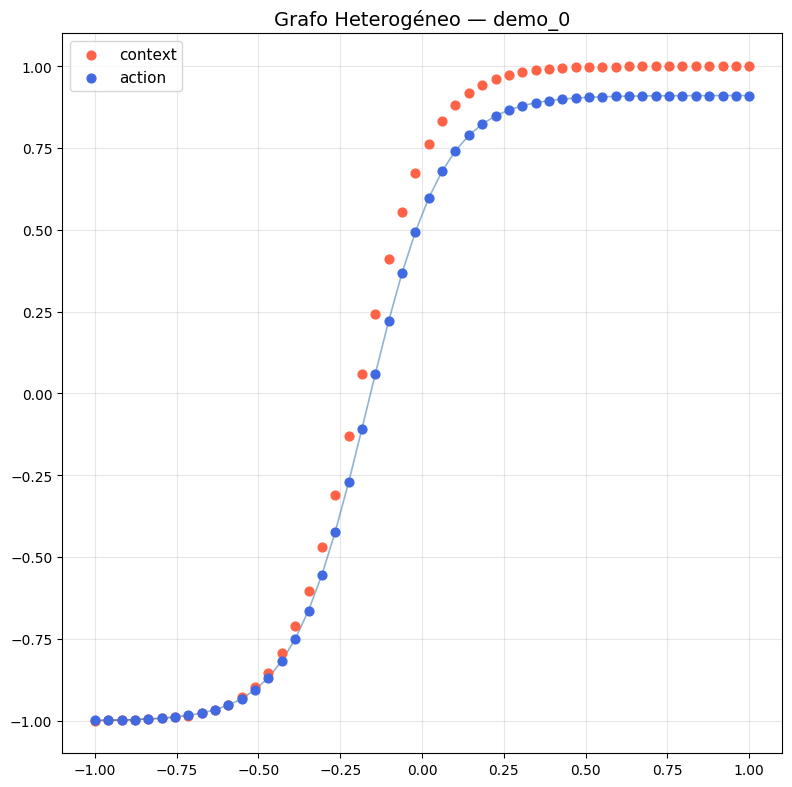

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_hetero_graph(graph: HeteroData, max_edges_shown: int = 30):
    ctx = graph['context'].x.numpy()
    act = graph['action'].x.numpy()
    edge_ac = graph['action', 'to', 'context'].edge_index.numpy()
    edge_aa = graph['action', 'to', 'action'].edge_index.numpy()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    ax.set_title("Grafo Heterogéneo — demo_0", fontsize=14)

    # Aristas action→context (gris, solo las primeras max_edges_shown)
    for i in range(min(max_edges_shown, edge_ac.shape[1])):
        s, d = edge_ac[0, i], edge_ac[1, i]
        ax.plot([act[s, 0], ctx[d, 0]], [act[s, 1], ctx[d, 1]],
                color='gray', alpha=0.3, linewidth=0.8, zorder=1)

    # Aristas action→action (azul)
    for i in range(edge_aa.shape[1]):
        s, d = edge_aa[0, i], edge_aa[1, i]
        ax.plot([act[s, 0], act[d, 0]], [act[s, 1], act[d, 1]],
                color='steelblue', alpha=0.6, linewidth=1.2, zorder=2)

    # Nodos
    ax.scatter(ctx[:, 0], ctx[:, 1], c='tomato',  s=40, zorder=3, label='context')
    ax.scatter(act[:, 0], act[:, 1], c='royalblue', s=40, zorder=3, label='action')

    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_hetero_graph(graph)


In [8]:
def iter_dataset_as_graphs(hdf5_path: str, k_neighbors: int = 5):
    """
    Generador que itera sobre todas las demos del HDF5
    y devuelve objetos HeteroData.
    """
    with h5py.File(hdf5_path, 'r') as f:
        demo_keys = sorted(f['data'].keys())
        for key in demo_keys:
            context = f['data'][key]['context'][:]
            target  = f['data'][key]['target'][:]
            yield key, build_hetero_graph(context, target, k_neighbors=k_neighbors)


# Verificación rápida: contar y chequear shapes
count = 0
for key, g in iter_dataset_as_graphs(HDF5_PATH):
    assert g['context'].x.shape == (50, 2)
    assert g['action'].x.shape  == (50, 2)
    count += 1

print(f"✅ {count} grafos generados correctamente")


✅ 1000 grafos generados correctamente
